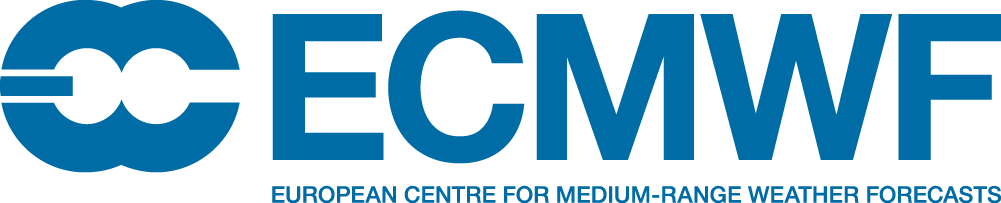
# Extreme Forecast Index (EFI) for 2 m temperature
## Case study: European heatwave, June 2026

A short, self-contained example of reading the **Extreme Forecast Index (EFI)** for 2 m temperature from the ECMWF static case-study dataset on AWS, and plotting it. For reference, the equivalent operational product is [EFI 2 m temperature](https://charts.ecmwf.int/products/efi2web_2t) on ECMWF Open Charts.

We use the forecast **initialised 25 June 2026**, valid **30 June 2026**. This run signalled the extreme heat across Europe several days ahead.

**If you want to know more about EFI**, how it is defined and calculated, see the Forecast User Guide: [EFI and Shift of Tails (SOT)](https://confluence.ecmwf.int/spaces/FUG/pages/673551287/Section+8.1.9+Extreme+Forecast+Index+-+EFI+and+Shift+of+Tails+-+SOT) and, more specifically, [Extreme Forecast Index - EFI](https://confluence.ecmwf.int/spaces/FUG/pages/673551296/Section+8.1.9.2+Extreme+Forecast+Index+-+EFI).

**Reminder, what EFI is *not*:** a magnitude. EFI saturates near +1 once the whole ensemble sits above the M-climate, so on its own it cannot tell you *how* extreme the forecast is. The proper companions are the Shift of Tails (SOT), the M-climate, or the raw ensemble. **SOT is not in this version of the dataset** (see the roadmap at the end); here we place plain 2 m temperature beside the EFI so the map has a magnitude to read against.

---
**Dataset:** [Case study dataset: European heatwave June 2026](https://confluence.ecmwf.int/spaces/DAC/pages/690467932/Case+study+dataset+European+heatwave+June+2026) (ECMWF Confluence)  
**DOI:** [10.5281/zenodo.21224650](https://doi.org/10.5281/zenodo.21224650)  
**Licence:** CC-BY 4.0 + ECMWF Terms of Use

## 1. Set up

The tools are ECMWF's own: **earthkit-data** to read the GRIB (via ecCodes) and **earthkit-plots** to draw the maps. The only outside library is **boto3**, AWS's storage client, which we use to pull files from the public S3 bucket. Requires ecCodes ≥ 2.42.0.

**Note:** if you are running this on MyBinder, or you already have the libraries installed, go straight to importing the libraries. Otherwise, uncomment and run the install cell below.

In [1]:
# !pip install --quiet earthkit-data earthkit-plots cfgrib boto3

Import the libraries.

In [2]:
import os
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import earthkit.data as ekd
import earthkit.plots as ekp

The dataset sits in a **public** S3 bucket, so we can read it anonymously with no AWS account or key needed. We point boto3 at the bucket and add a small helper that downloads one file locally (earthkit reads GRIB from a local path).

In [3]:
BUCKET = "ecmwf-static-datasets"
PREFIX = "heatwave/june-2026"

# UNSIGNED = anonymous access (no credentials).
s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
os.makedirs("data", exist_ok=True)

def fetch(key):
    """Download one S3 object into ./data and return its local path."""
    local = os.path.join("data", key.split("/")[-1])
    if not os.path.exists(local):
        s3.download_file(BUCKET, key, local)
    return local

## 2. Find the files

Each forecast **initialisation** has its own folder (`<prefix>/<init-date>/`). Inside, two file families sit side by side:

- **EFI** files, `..._enfo_efi_...`
- **Forecast** files, `..._oper_fc_...` (these carry the thermofeel indices and plain 2 m temperature)

The structure is worth understanding before you start: **all EFI steps for a run live in a single file**, whereas the other parameters are **split into one file per step**. That is why there are only a couple of EFI files but many forecast files. The forecast files are stored at 3-hourly steps (0h, 3h, 6h …). Note that EFI is different: it is not an instantaneous step but a value over a period, as we'll see in the next section. Let's list the files.

In [4]:
INIT = "20260625"  # initialisation date

resp = s3.list_objects_v2(Bucket=BUCKET, Prefix=f"{PREFIX}/{INIT}/")
keys = [o["Key"] for o in resp.get("Contents", [])]
efi_keys = sorted(k for k in keys if "_enfo_efi_" in k)
fc_keys  = sorted(k for k in keys if "_oper_fc_" in k)

print(f"{len(efi_keys)} EFI files, {len(fc_keys)} forecast files\n")

# EFI: one file per run (per initialisation time), containing all steps.
print("EFI files (all steps inside each):")
for k in efi_keys:
    print("   ", k.split("/")[-1])

# Forecast: one file per step. Show the first few and the step spacing.
print("\nForecast files (one per step), first 6:")
for k in fc_keys[:6]:
    print("   ", k.split("/")[-1])

print("\nSteps available in the forecast files:")
print(sorted({k.split("_")[-1] for k in fc_keys}, key=lambda s: int(s.rstrip("h"))))

2 EFI files, 170 forecast files

EFI files (all steps inside each):
    ecm_wf_ifs-ens_od_enfo_efi_20260625T000000Z_20260705T000000Z_240h
    ecm_wf_ifs-ens_od_enfo_efi_20260625T120000Z_20260705T120000Z_240h

Forecast files (one per step), first 6:
    ecm_wf_ifs-ens-cf_od_oper_fc_20260625T000000Z_20260625T000000Z_0h
    ecm_wf_ifs-ens-cf_od_oper_fc_20260625T000000Z_20260625T030000Z_3h
    ecm_wf_ifs-ens-cf_od_oper_fc_20260625T000000Z_20260625T060000Z_6h
    ecm_wf_ifs-ens-cf_od_oper_fc_20260625T000000Z_20260625T090000Z_9h
    ecm_wf_ifs-ens-cf_od_oper_fc_20260625T000000Z_20260625T120000Z_12h
    ecm_wf_ifs-ens-cf_od_oper_fc_20260625T000000Z_20260625T150000Z_15h

Steps available in the forecast files:
['0h', '3h', '6h', '9h', '12h', '15h', '18h', '21h', '24h', '27h', '30h', '33h', '36h', '39h', '42h', '45h', '48h', '51h', '54h', '57h', '60h', '63h', '66h', '69h', '72h', '75h', '78h', '81h', '84h', '87h', '90h', '93h', '96h', '99h', '102h', '105h', '108h', '111h', '114h', '117h', '120h'

## 3. EFI steps are *ranges*, not instants

This is the one thing worth pausing on. EFI is a period statistic, so every field is valid over a **time window** such as `0-24`, `24-48`, and also overlapping multi-day spans like `0-120` or `48-120`. There is no "EFI at +120 h", only "EFI for the window *ending* at +120 h". These are the same period-mean fields you see on the Open Charts EFI products. So we never pick EFI by a single step, instead we pick it by its window.

Reference: [ECMWF Forecast User Guide: EFI charts](https://confluence.ecmwf.int/spaces/FUG/pages/673551357/Section+8.1.9.7+EFI+Charts).

#### The two daily runs carry different windows

This dataset holds EFI from two runs per day, **00 and 12 UTC** (there are no 06/18 EFI files). A given valid day is reached at *different lead times* from each run, so the two files do not list the same set of windows. The Forecast User Guide notes that EFI distributions for a day come from different, consecutive ensemble runs, so their lead times vary.

The FUG also lists the standard EFI periods: single days (Day 1, 2, 3 …) and overlapping multi-day means (1-3, 2-4, 1-5, 1-10, 1-15 …), each valid over a 00-24 UTC period. That is why the tables below show both 24-hour windows and longer spans. Every EFI field is a **mean over its window**, not an instantaneous value.

First, the **00 UTC** run, listed with the window boundaries (`stepRange`, `startStep`, `endStep`):

In [5]:
efi_00 = ekd.from_source("file", fetch(efi_keys[0])).to_fieldlist()
efi_00.ls(keys=["parameter.variable", "time.base_datetime",
                "metadata.stepRange", "metadata.startStep",
                "metadata.endStep", "time.valid_datetime"])

,parameter.variable,time.base_datetime,metadata.stepRange,metadata.startStep,metadata.endStep,time.valid_datetime
0,2ti,2026-06-25,0-120,0,120,2026-06-30
1,2ti,2026-06-25,0-24,0,24,2026-06-26
2,2ti,2026-06-25,0-240,0,240,2026-07-05
3,2ti,2026-06-25,0-72,0,72,2026-06-28
4,2ti,2026-06-25,120-144,120,144,2026-07-01
5,2ti,2026-06-25,120-192,120,192,2026-07-03
6,2ti,2026-06-25,144-168,144,168,2026-07-02
7,2ti,2026-06-25,144-216,144,216,2026-07-04
8,2ti,2026-06-25,24-144,24,144,2026-07-01
9,2ti,2026-06-25,24-48,24,48,2026-06-27


Now the **12 UTC** run from the same date. The step numbers look different, but they describe the *same* daily periods, just counted from a base time 12 hours later. For example, the 24-hour window valid **30 June** is `96-120` in the 00 UTC run and `84-108` in the 12 UTC run. It's the same period, offset by 12 h because the second run started 12 h later.

This is also why the two tables display differently: the 00 UTC run's base and window ends fall on midnight, so `.ls()` shows just the date, while the 12 UTC run's base is at 12:00, so it shows the full timestamp. Same data, different base time.

In [6]:
efi_12 = ekd.from_source("file", fetch(efi_keys[1])).to_fieldlist()
efi_12.ls(keys=["parameter.variable", "time.base_datetime",
                "metadata.stepRange", "metadata.startStep",
                "metadata.endStep", "time.valid_datetime"])

,parameter.variable,time.base_datetime,metadata.stepRange,metadata.startStep,metadata.endStep,time.valid_datetime
0,2ti,2026-06-25 12:00:00,0-240,0,240,2026-07-05 12:00:00
1,2ti,2026-06-25 12:00:00,108-132,108,132,2026-07-01 00:00:00
2,2ti,2026-06-25 12:00:00,108-180,108,180,2026-07-03 00:00:00
3,2ti,2026-06-25 12:00:00,108-228,108,228,2026-07-05 00:00:00
4,2ti,2026-06-25 12:00:00,12-132,12,132,2026-07-01 00:00:00
5,2ti,2026-06-25 12:00:00,12-36,12,36,2026-06-27 00:00:00
6,2ti,2026-06-25 12:00:00,12-84,12,84,2026-06-29 00:00:00
7,2ti,2026-06-25 12:00:00,132-156,132,156,2026-07-02 00:00:00
8,2ti,2026-06-25 12:00:00,132-204,132,204,2026-07-04 00:00:00
9,2ti,2026-06-25 12:00:00,156-180,156,180,2026-07-03 00:00:00


In [7]:
# We map from the 00 UTC run in the rest of the notebook.
efi = efi_00

The `stepRange`, `startStep` and `endStep` columns above are GRIB metadata keys describing each window. You can also query them on any single field directly, which is how we select a window below.

In [8]:
# The metadata keys that expose the window, shown for the first field.
f0 = efi[0]
for key in ("stepRange", "startStep", "endStep", "validityDate"):
    print(f"{key:14s} = {f0.metadata(key)}")

stepRange      = 0-120
startStep      = 0
endStep        = 120
validityDate   = 20260630


Several rows share the same validity date, those are the overlapping windows. Pull out everything valid on **30 June** and show each window's start and end step, so the ranges are explicit.

In [9]:
TARGET = "20260630"  # the day we want to map
valid_target = [f for f in efi if str(f.metadata("validityDate")) == TARGET]

for f in valid_target:
    print(f"window {f.metadata('startStep')}-{f.metadata('endStep')} h")

window 0-120 h
window 48-120 h
window 96-120 h


For a single-day map we want the **24-hour** window (end minus start = 24 h). The wider windows (`0-120`, `48-120`) average EFI over several days, which is useful for a persistent spell, but not what we want here.

In [10]:
daily = [f for f in valid_target
         if int(f.metadata("endStep")) - int(f.metadata("startStep")) == 24]
efi_field = daily[0]
print("Using window:", f"{efi_field.metadata('startStep')}-{efi_field.metadata('endStep')} h")

Using window: 96-120 h


## 4. Plot the EFI

We plot the daily EFI window using ECMWF's standard EFI colour scale, so the map matches the operational EFI charts. EFI runs from -1 to +1 and its sign shows a warm or cold anomaly. As a guide (Forecast User Guide): values between 0.5 and 0.8 signify "unusual" weather is likely, and above 0.8 "very unusual" or extreme. The signal is strongest where |EFI| approaches 1.

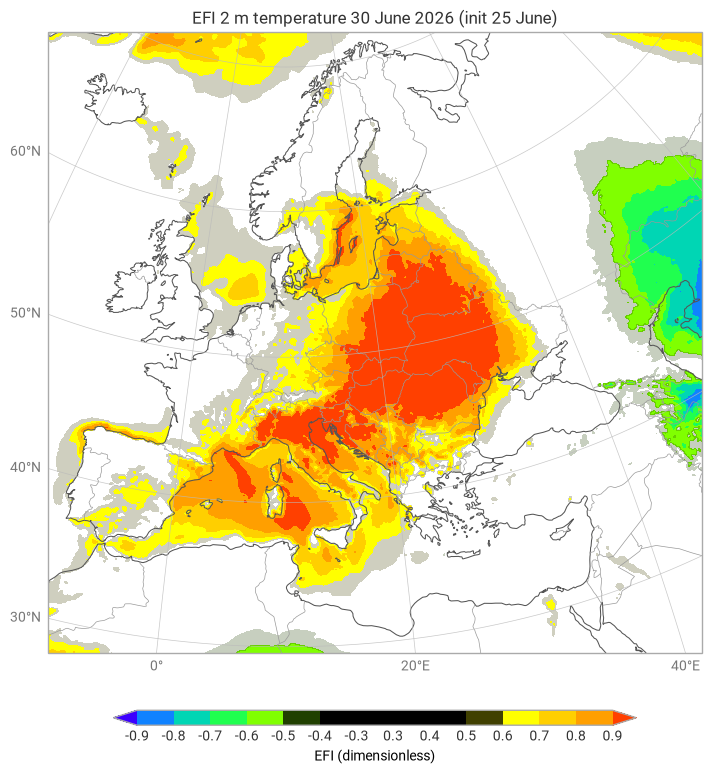

In [11]:
fig = ekp.Map(domain="Europe")
fig.contourf(efi_field, style=ekp.styles.load_style("sh-blured-fm1t1lst"))
fig.coastlines()
fig.borders()
fig.gridlines()
fig.title("EFI 2 m temperature 30 June 2026 (init 25 June)")
fig.legend(label="EFI (dimensionless)")
fig.show()

## 5. Give the EFI a magnitude to read against

Over the worst-hit regions the EFI is pinned near +1, where the whole ensemble is above climate, so it has stopped discriminating: +1 over Iberia and +1 over central Europe do not mean the same absolute heat. To recover magnitude we place plain **2 m temperature** beside it. (The proper companion is SOT, see section 6. The dataset also carries the thermofeel human-comfort indices: UTCI, heat index, apparent temperature and WBGT, described on the [FUG thermal parameters](https://confluence.ecmwf.int/spaces/FUG/pages/673551030/Section+8.1.18+Thermal+parameters) page. We use 2 m temperature here as the clearest magnitude.)

We need the forecast file valid at the same time as our EFI window: 30 June, **12 UTC** (the daytime peak). Match the initialisation and validity times in the filename.

In [12]:
chosen = None
for k in fc_keys:
    if (INIT + "T00" in k) and (TARGET + "T12" in k):
        chosen = k
print("Using:", chosen.split("/")[-1])

Using: ecm_wf_ifs-ens-cf_od_oper_fc_20260625T000000Z_20260630T120000Z_132h


Open it and list the fields. These forecast files mix GRIB editions (the thermofeel indices are GRIB2, the 2 m temperature is GRIB1); earthkit reads them together.

In [13]:
# NOTE: if 2t is missing below, restore the edition filter:
#   ekd.from_source("file", fetch(chosen), filter_by_keys={"edition": 1})
fc = ekd.from_source("file", fetch(chosen)).to_fieldlist()
fc.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,2r,2026-06-30 12:00:00,2026-06-25,5 days 12:00:00,2,height_above_ground_level,NaN,regular_ll
1,aptmp,2026-06-30 12:00:00,2026-06-25,5 days 12:00:00,0,surface,NaN,regular_ll
2,2t,2026-06-30 12:00:00,2026-06-25,5 days 12:00:00,0,surface,0,regular_ll
3,utci,2026-06-30 12:00:00,2026-06-25,5 days 12:00:00,0,surface,NaN,regular_ll
4,heatx,2026-06-30 12:00:00,2026-06-25,5 days 12:00:00,0,surface,NaN,regular_ll
5,wbgt,2026-06-30 12:00:00,2026-06-25,5 days 12:00:00,0,surface,NaN,regular_ll


Select 2 m temperature (using the same key name `.ls()` shows) and plot it in Celsius.

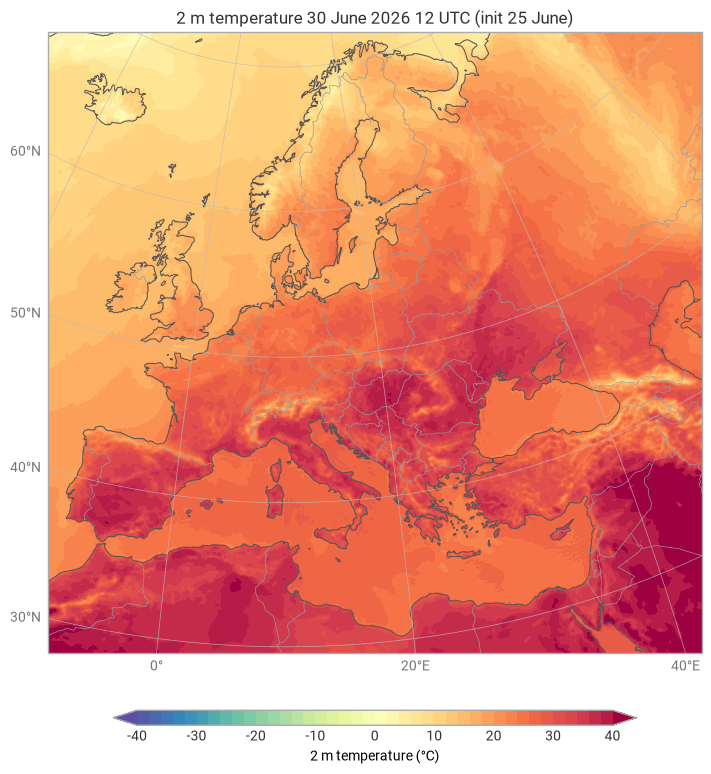

In [14]:
t2m = fc.sel({"parameter.variable": "2t"})

fig = ekp.Map(domain="Europe")
fig.contourf(t2m, style=ekp.styles.load_style("2m-temperature-spectral-celsius"))
fig.coastlines()
fig.borders()
fig.gridlines()
fig.title("2 m temperature 30 June 2026 12 UTC (init 25 June)")
fig.legend(label="2 m temperature (°C)")
fig.show()

## 6. Roadmap: SOT and M-climate

The proper companion to EFI is the **Shift of Tails (SOT)**: where EFI = +1, SOT tells you *how far past* the climate extreme the forecast tail sits. This is exactly the magnitude EFI loses when it saturates. ECMWF pairs the two in its own products (e.g. the [sub-seasonal EFI/SOT chart](https://charts.ecmwf.int/products/extended-efi-sot-2t)).

SOT and the M-climate are **not** in this version of the dataset and cannot be reconstructed from it (neither the raw ensemble nor the M-climate is archived). They are expected in a future release, i.e. either an updated version of this dataset or a companion dataset.

If you are reading this at a time when they are already available, you can read SOT with the same pattern as EFI above: `.to_fieldlist()`, then select by validity date, filter to the 24 h window, and plot beside the EFI map.

## 7. Citation

Pidduck, E., *et al.* (2026). *ECMWF EFI and Thermofeel heat-stress indicators for the June 2026 European heatwave* (Version 1.0.0) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.21224650

Dataset documentation: [Case study dataset: European heatwave June 2026](https://confluence.ecmwf.int/spaces/DAC/pages/690467932/Case+study+dataset+European+heatwave+June+2026)

Licence: CC-BY 4.0 + ECMWF Terms of Use.

<sub>In applying this licence, ECMWF does not waive the privileges and immunities granted to it by virtue of its status as an intergovernmental organisation nor does it submit to any jurisdiction.</sub>